In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_tox21()
train_dataset, valid_dataset, test_dataset = datasets


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\elisa\.conda\envs\deepchem310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\elisa\.conda\envs\deepchem310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\elisa\.conda\envs\deepchem310\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\elisa\.conda\envs\deepchem310\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    a

In [3]:
print(train_dataset.X.shape)
print(train_dataset.y.shape)

print("Number of tasks:", len(tasks))
print("Train X shape:", train_dataset.X.shape)
print("Train y shape:", train_dataset.y.shape)
print("First 5 tasks:", tasks[:5])

(6258, 1024)
(6258, 12)
Number of tasks: 12
Train X shape: (6258, 1024)
Train y shape: (6258, 12)
First 5 tasks: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER']


In [4]:
# importing the SMILES data from the dataset

smiles = train_dataset.ids
label = train_dataset.y

print(smiles[:5])
print(label[:5])

# convert them into dataframe
df = pd.DataFrame({
    "smiles": train_dataset.ids,
    "labels": train_dataset.y.tolist()
})

df.head()

['CC(O)(P(=O)(O)O)P(=O)(O)O' 'CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C'
 'OC[C@H](O)[C@@H](O)[C@H](O)CO'
 'CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]' 'CC(C)COC(=O)C(C)C']
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


,smiles,labels
0,CC(O)(P(=O)(O)O)P(=O)(O)O,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,OC[C@H](O)[C@@H](O)[C@H](O)CO,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,CC(C)COC(=O)C(C)C,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


## Create a Baseline

#### Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

task = 0   # choose one toxicity target

X_train = train_dataset.X
y_train = train_dataset.y[:, task]
w_train = train_dataset.w[:, task]

X_valid = valid_dataset.X
y_valid = valid_dataset.y[:, task]
w_valid = valid_dataset.w[:, task]

# remove missing labels
train_mask = w_train != 0
valid_mask = w_valid != 0

model = LogisticRegression(max_iter=1000)

model.fit(X_train[train_mask], y_train[train_mask])

pred = model.predict_proba(X_valid[valid_mask])[:,1]

auc = roc_auc_score(y_valid[valid_mask], pred)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.7688793585679656


In [15]:
# using L2 regularization and class balancing

model_L2 = LogisticRegression(max_iter=1000, C=0.02, penalty="l2", class_weight="balanced")

model_L2.fit(X_train[train_mask], y_train[train_mask])

pred = model_L2.predict_proba(X_valid[valid_mask])[:,1]

logreg_auc = roc_auc_score(y_valid[valid_mask], pred)

print("Validation ROC-AUC after L2 regularization and class balancing:", auc)

Validation ROC-AUC after L2 regularization and class balancing: 0.7759045956951717


In [10]:
C_values = [0.05, 0.1, 0.2, 0.3]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty="l2",
        class_weight="balanced",
        max_iter=2000
    )
    # fit/evaluate here

    model.fit(X_train[train_mask], y_train[train_mask])

    pred = model.predict_proba(X_valid[valid_mask])[:,1]

    auc = roc_auc_score(y_valid[valid_mask], pred)
    results.append(auc)
    
results

[0.77946112250606, 0.7777363415998509, 0.7716296848778669, 0.7660824165578968]

The best model for logistic regression is using C=0.02 with ROC-AUC value result is 0.77946112250606.

In [7]:
# multitask QSAR modeling for Logistic Regression model

lr_scores = []

for task in range(len(tasks)):

    X_train = train_dataset.X
    y_train = train_dataset.y[:, task]
    w_train = train_dataset.w[:, task]

    X_valid = valid_dataset.X
    y_valid = valid_dataset.y[:, task]
    w_valid = valid_dataset.w[:, task]

    train_mask = w_train != 0
    valid_mask = w_valid != 0

    # skip tasks without both classes
    if len(np.unique(y_train[train_mask])) < 2:
        lr_scores.append(np.nan)
        continue

    model = LogisticRegression(
        C=0.02,
        penalty="l2",
        class_weight="balanced",
        max_iter=2000
    )

    model.fit(X_train[train_mask], y_train[train_mask])

    pred = model.predict_proba(X_valid[valid_mask])[:,1]

    auc = roc_auc_score(y_valid[valid_mask], pred)

    lr_scores.append(auc)

print("Per-task ROC-AUC:", lr_scores)
print("Mean ROC-AUC:", np.nanmean(lr_scores))

Per-task ROC-AUC: [0.7747063210889428, 0.838139534883721, 0.7883069743323826, 0.725, 0.6328183716075158, 0.763779527559055, 0.7221966911764706, 0.7161842578787723, 0.7168294344764933, 0.705360205831904, 0.7960151587355616, 0.7079232111692845]
Mean ROC-AUC: 0.7406049740616752


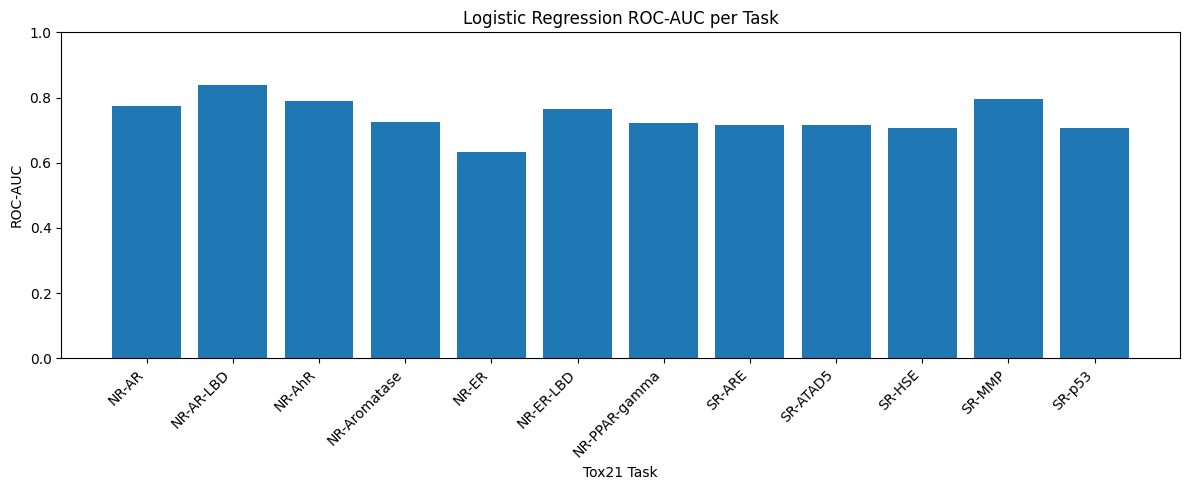

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(tasks, lr_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Tox21 Task")
plt.title("Logistic Regression ROC-AUC per Task")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

#### Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    class_weight="balanced",
    random_state=0
)

model_rf.fit(X_train[train_mask], y_train[train_mask])

pred = model_rf.predict_proba(X_valid[valid_mask])[:,1]

rf_auc = roc_auc_score(y_valid[valid_mask], pred)

print("Validation ROC-AUC RF model:", auc)

Validation ROC-AUC RF model: 0.7079232111692845


In [11]:
model_rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=0,
    max_features="sqrt"
)

model_rf.fit(X_train[train_mask], y_train[train_mask])

pred = model_rf.predict_proba(X_valid[valid_mask])[:,1]

rf_auc = roc_auc_score(y_valid[valid_mask], pred)

print("Validation ROC-AUC RF model:", auc)

Validation ROC-AUC RF model: 0.7079232111692845


In [12]:
# multi-task QSAR modeling

rf_scores = []

for task in range(len(tasks)):

    X_train = train_dataset.X
    y_train = train_dataset.y[:, task]
    w_train = train_dataset.w[:, task]

    X_valid = valid_dataset.X
    y_valid = valid_dataset.y[:, task]
    w_valid = valid_dataset.w[:, task]

    train_mask = w_train != 0
    valid_mask = w_valid != 0

    # skip tasks without both classes
    if len(np.unique(y_train[train_mask])) < 2:
        rf_scores.append(np.nan)
        continue

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=0
    )

    model.fit(X_train[train_mask], y_train[train_mask])

    pred = model.predict_proba(X_valid[valid_mask])[:,1]

    auc = roc_auc_score(y_valid[valid_mask], pred)

    rf_scores.append(auc)

print("Per-task ROC-AUC:", rf_scores)
print("Mean ROC-AUC:", np.nanmean(rf_scores))

Per-task ROC-AUC: [0.7720725340294611, 0.8419269102990032, 0.7876263935701322, 0.7229885057471265, 0.6382045929018789, 0.7945696443117025, 0.7694738051470588, 0.7505912292427126, 0.6890529184646832, 0.7159305317324186, 0.8052284022057321, 0.7759045956951717]
Mean ROC-AUC: 0.7552975052789234


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(tasks, rf_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Tox21 Task")
plt.title("Random Forest ROC-AUC per Task")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

##### Saving the data to make table result comparison later

In [16]:
import pandas as pd

results_table = []

results_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
    ],
    "ROC-AUC": [
        logreg_auc,
        rf_auc,
    ]
})

results_table.to_csv("result_comparison.csv", index=False)

In [30]:
rt = pd.read_csv("result_comparison.csv", sep=",")
rt.head()

,Model,ROC-AUC
0,Logistic Regression,0.707923
1,Random Forest,0.774706


In [26]:
classic_per_task_table = []

classic_per_task_table = pd.DataFrame({
    "Task": tasks,
    "Logistic Regression": lr_scores,
    "Random Forest": rf_scores
})

classic_per_task_table.to_csv("classic_per_task_table.csv", index=False)

In [27]:
ct = pd.read_csv("classic_per_task_table.csv", sep=",")
ct.head()

,Task,Logistic Regression,Random Forest
0,NR-AR,0.774706,0.772073
1,NR-AR-LBD,0.838140,0.841927
2,NR-AhR,0.788307,0.787626
3,NR-Aromatase,0.725000,0.722989
4,NR-ER,0.632818,0.638205


#### DeepChem neural baseline
##### Multitask Classifier

In [1]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_tox21()
train_dataset, valid_dataset, test_dataset = datasets

n_tasks = len(tasks)
n_features = train_dataset.X.shape[1]

model = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=[1000],
    dropouts=0.2,
    learning_rate=0.0005
)

model.fit(train_dataset, nb_epoch=30)

metric = dc.metrics.Metric(dc.metrics.roc_auc_score)

nn_valid_scores = model.evaluate(valid_dataset, [metric], transformers)

print("NN validation:", nn_valid_scores["roc_auc_score"])

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (C:\Users\elisa\.conda\envs\tox21_gnn\lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric dependen

NN validation: 0.6974688772960776


In [2]:
# comparing to other layer_size

tasks, datasets, transformers = dc.molnet.load_tox21()
train_dataset, valid_dataset, test_dataset = datasets

n_tasks = len(tasks)
n_features = train_dataset.X.shape[1]

model = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=[512, 256],
    dropouts=0.2,
    learning_rate=0.0005
)

model.fit(train_dataset, nb_epoch=30)

metric = dc.metrics.Metric(dc.metrics.roc_auc_score)

nn_valid_scores = model.evaluate(valid_dataset, [metric], transformers)

print("NN validation:", nn_valid_scores["roc_auc_score"])

NN validation: 0.7055040006926272


In [3]:
# per task ROC-AUC
from sklearn.metrics import roc_auc_score
import numpy as np

train_dataset_fixed = dc.data.NumpyDataset(
    X=train_dataset.X.astype(np.float32),
    y=train_dataset.y.astype(np.float32),
    w=train_dataset.w.astype(np.float32),
    ids=train_dataset.ids
)

valid_dataset_fixed = dc.data.NumpyDataset(
    X=valid_dataset.X.astype(np.float32),
    y=valid_dataset.y.astype(np.float32),
    w=valid_dataset.w.astype(np.float32),
    ids=valid_dataset.ids
)

pred = model.predict(valid_dataset_fixed)
MC_scores = []

for task_idx in range(len(tasks)):
    y_true = valid_dataset_fixed.y[:, task_idx]
    w = valid_dataset_fixed.w[:, task_idx]
    mask = w != 0

    if len(np.unique(y_true[mask])) < 2:
        MC_scores.append(np.nan)
        continue

    y_score = pred[:, task_idx, 1]
    auc = roc_auc_score(y_true[mask], y_score[mask])
    MC_scores.append(auc)

for task, auc in zip(tasks, MC_scores):
    print(task, auc)

print("Mean ROC-AUC:", np.nanmean(MC_scores))

NR-AR 0.7600223755360805
NR-AR-LBD 0.7888372093023256
NR-AhR 0.7538458214501771
NR-Aromatase 0.6915229885057471
NR-ER 0.6061238691718859
NR-ER-LBD 0.6860711376595167
NR-PPAR-gamma 0.7296645220588235
SR-ARE 0.7150789162510925
SR-ATAD5 0.7216443334090392
SR-HSE 0.687778730703259
SR-MMP 0.7654026822792566
SR-p53 0.6750203606748109
Mean ROC-AUC: 0.715084412250168


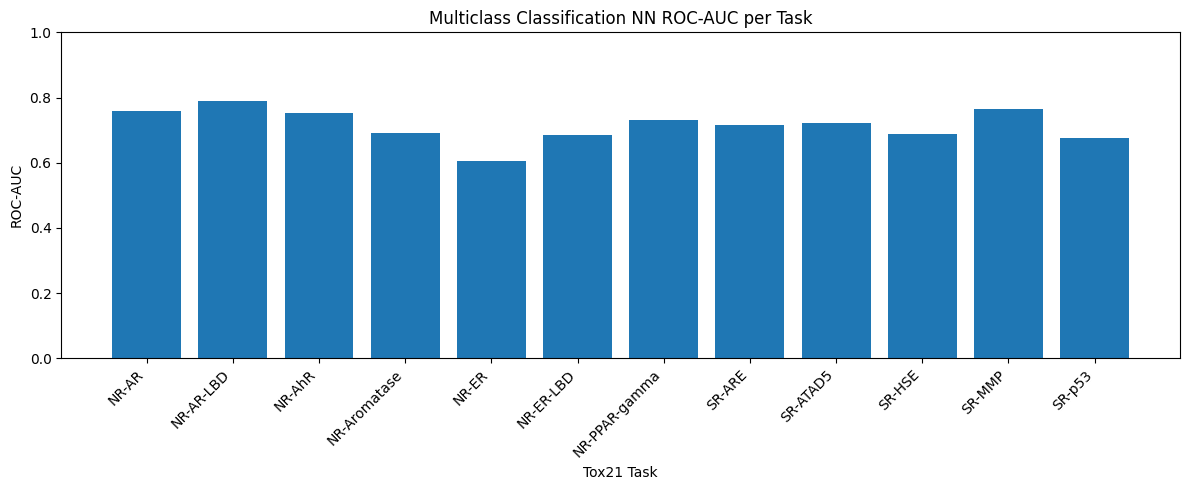

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(tasks, MC_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Tox21 Task")
plt.title("Multiclass Classification NN ROC-AUC per Task")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

##### Graph Neural Network

In [5]:
import deepchem as dc
from deepchem.models import GCNModel

featurizer = dc.feat.MolGraphConvFeaturizer()

tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer=featurizer
)

train_dataset, valid_dataset, test_dataset = datasets

model = GCNModel(
    n_tasks=len(tasks),
    mode="classification",
    batch_size=32,
    learning_rate=0.0005
)

model.fit(train_dataset, nb_epoch=50)

metric = dc.metrics.Metric(dc.metrics.roc_auc_score)

gcn_valid_scores = model.evaluate(valid_dataset, [metric], transformers)

print("GCN validation:", gcn_valid_scores["roc_auc_score"])

C:\Users\elisa\.conda\envs\tox21_gnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GCN validation: 0.7607146662544868


In [ ]:
# per task ROC-AUC
from sklearn.metrics import roc_auc_score
import numpy as np

train_dataset_fixed = dc.data.NumpyDataset(
    X=train_dataset.X.astype(np.float32),
    y=train_dataset.y.astype(np.float32),
    w=train_dataset.w.astype(np.float32),
    ids=train_dataset.ids
)

valid_dataset_fixed = dc.data.NumpyDataset(
    X=valid_dataset.X.astype(np.float32),
    y=valid_dataset.y.astype(np.float32),
    w=valid_dataset.w.astype(np.float32),
    ids=valid_dataset.ids
)

pred = model.predict(valid_dataset_fixed)
GCN_scores = []

for task_idx in range(len(tasks)):
    y_true = valid_dataset_fixed.y[:, task_idx]
    w = valid_dataset_fixed.w[:, task_idx]
    mask = w != 0

    if len(np.unique(y_true[mask])) < 2:
        GCN_scores.append(np.nan)
        continue

    y_score = pred[:, task_idx, 1]
    auc = roc_auc_score(y_true[mask], y_score[mask])
    GCN_scores.append(auc)

for task, auc in zip(tasks, GCN_scores):
    print(task, auc)

print("Mean ROC-AUC:", np.nanmean(GCN_scores))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(tasks, per_task_scores)
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.xlabel("Tox21 Task")
plt.title("GCN ROC-AUC per Task")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

##### Attentive FP Model

In [ ]:
from rdkit import RDLogger
from deepchem.models import AttentiveFPModel

# optional: silence RDKit warnings
RDLogger.DisableLog('rdApp.*')

# AttentiveFPModel uses graph features from MolGraphConvFeaturizer
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)

tasks, datasets, transformers = dc.molnet.load_tox21(featurizer=featurizer, reload=False)

train_dataset, valid_dataset, test_dataset = datasets

model = AttentiveFPModel(
    n_tasks=len(tasks),
    mode="classification",
    batch_size=32,
    learning_rate=0.001,
    num_layers=2,
    num_timesteps=2,
    graph_feat_size=200,
    dropout=0.2
)

model.fit(train_dataset, nb_epoch=20)

metric = dc.metrics.Metric(dc.metrics.roc_auc_score)

att_valid_scores = model.evaluate(valid_dataset, [metric], transformers)

print("Validation ROC-AUC:", att_valid_scores["roc_auc_score"])

Failed to featurize datapoint 95, [I-].[K+]. Appending empty array
Exception message: tuple index out of range
Failed to featurize datapoint 255, [Hg+2]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 659, [Ba+2]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 985, [TlH2+]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
Failed to feat

##### Saving the Table Results (ROC-AUC) in Neural Network

In [12]:
import pandas as pd

results_table = []

results_table = pd.DataFrame({
    "Model": [
        "Multiclass Classification",
        "Graph Convolution Network",
        "AttentiveFP"
    ],
    "ROC-AUC": [
        nn_valid_scores["roc_auc_score"],
        gcn_valid_scores["roc_auc_score"],
        att_valid_scores["roc_auc_score"]
    ]
})

results_table.to_csv("nnresults.csv", index=False)

NameError: name 'rf_auc' is not defined

In [ ]:
classic_per_task_table = []

classic_per_task_table = pd.DataFrame({
    "Task": tasks,
    "MultiClassification NN": per_task_scores,
    "Random Forest": rf_scores
})

classic_per_task_table.to_csv("classic_per_task_table.csv", index=False)

In [6]:
bs = pd.read_csv("result_comparison.csv")
nn = pd.read_csv("nnresults.csv")

final_table = pd.concat([bs, nn], ignore_index=True)

final_table.to_csv("final_comparison_results", index = False)

In [7]:
final_table

,Model,ROC-AUC
0,Logistic Regression,0.777736
1,Random Forest,0.772073
2,Multitask NN,0.704250
3,Graph NN,0.750154
